# Performance enhancement and organizational analysis

Connect activity service times, case cycle times, rework, handovers, and cohorts. These are clues for improvement, not automatic causal explanations.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
while not (root / 'labs').exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
from labs.common import load_module, load_variant_lab
lab = load_module('performance_lab', root / 'labs/04-performance-organization/performance_lab.py')
events = load_variant_lab().generate_event_log()
activity, cases, handovers, cohorts = lab.analyze_performance(events)
display(activity)
display(cohorts.head(10))

,activity,events,median_hours,p90_hours
0,Rework,27,6.869874,11.751350
1,Clarify,50,5.704319,8.291502
2,Ship,222,2.888864,4.395293
3,Pack,33,1.599699,2.655200
4,Check,290,1.332673,2.030445
5,Approve,249,0.819522,1.284131
6,Reject,18,0.413843,0.590207
7,Receive,240,0.311801,0.472432


,channel,product_type,cases,median_cycle,adverse_rate
0,direct,custom,12,14.490702,0.416667
1,direct,service,6,11.493722,0.333333
4,partner,custom,18,9.387875,0.555556
8,web,custom,34,8.357862,0.470588
6,partner,standard,52,7.809736,0.423077
2,direct,standard,15,7.330867,0.200000
10,web,standard,66,6.825046,0.272727
9,web,service,11,6.749305,0.272727
5,partner,service,9,6.680932,0.444444
7,partner,NaN,6,6.446975,0.166667


,source,target,count
0,Sales,Risk,290
1,Risk,Risk,240
2,Risk,Logistics,189
3,Risk,Sales,50
4,Risk,Warehouse,33
5,Warehouse,Logistics,33
6,Risk,Quality,27
7,Quality,Risk,27


,count,mean,std,min,25%,50%,75%,max
rework,,,,,,,,
0,163.0,6.417108,1.986305,1.943334,5.311627,6.387387,7.578649,11.017070
1,77.0,15.596581,3.491431,9.480517,13.486257,14.606789,16.820899,32.529111


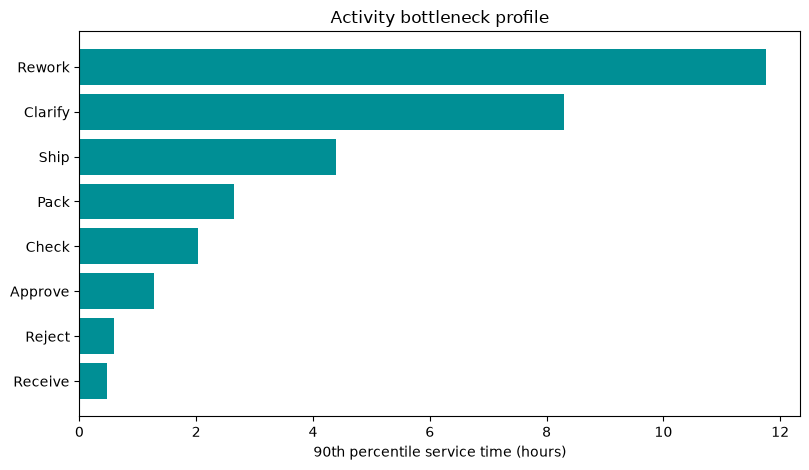

In [2]:
lab.plot_activity(activity)
display(handovers.head(10))
display(cases.groupby('rework')['cycle_hours'].describe())

## Improvement hypothesis

Write one evidence chain: operational question, measured pattern, plausible mechanism, domain validation needed, proposed intervention, and success metric. Avoid ranking individual workers.